# 10a_rawg_data_fetcher.ipynb
Descarga datos de la RAWG API para los 3,682 juegos del dataset y los guarda localmente.
Ejecutar **una sola vez** — los datos quedan en `../Data/rawg_enriched.jsonl` y `../Data/rawg_enriched.csv`.

**API:** https://rawg.io/apidocs — 20,000 requests/mes gratis.
**Rate limit:** 0.35s entre requests (~2hs para dataset completo).
**Resume:** Si se interrumpe, re-ejecutar retoma desde el ultimo juego procesado.

In [1]:
# ============================================================
# CONFIGURACION  — API key de rawg.io/apidocs
# ============================================================
RAWG_API_KEY = "84d0a3c5a5864a64858025fc68a28323"

# Paths
import os, pathlib
BASE      = pathlib.Path("../Data")
OUT_JSONL = BASE / "rawg_enriched.jsonl"   # una linea JSON por juego, append-friendly
OUT_CSV   = BASE / "rawg_enriched.csv"     # tabla final
LOG_FILE  = BASE / "rawg_fetch_log.json"   # progreso (ids ya procesados)

# Rate limiting
DELAY_SEARCH  = 0.35   # segundos entre requests de busqueda
DELAY_DETAIL  = 0.35   # segundos entre requests de detalle
SAVE_EVERY    = 100    # guardar progreso cada N juegos

assert RAWG_API_KEY != "TU_API_KEY_AQUI", "Reemplaza RAWG_API_KEY con tu clave real!"
print(f"API key configurada: {RAWG_API_KEY[:6]}...")
print(f"Output: {OUT_JSONL}")

API key configurada: 84d0a3...
Output: ..\Data\rawg_enriched.jsonl


In [2]:
import ast, json, time, requests
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

print("Imports OK")

Imports OK


c:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cargar juegos del dataset (solo los 3682 con item_idx)
with open(BASE / "item2idx.json") as f:
    item2idx = {k: int(v) for k, v in json.load(f).items()}

steam_id_to_item_idx = {str(k): int(v) for k, v in item2idx.items()}

games_raw = []
with open(BASE / "steam_games.json", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        g = ast.literal_eval(line)
        steam_id = str(g.get("id", ""))
        if steam_id in steam_id_to_item_idx:
            g["item_idx"] = steam_id_to_item_idx[steam_id]
            games_raw.append(g)

print(f"Juegos a consultar: {len(games_raw)}")
print(f"Ejemplo: {games_raw[0].get('app_name')} (steam_id={games_raw[0].get('id')}, item_idx={games_raw[0]['item_idx']})")

Juegos a consultar: 3195
Ejemplo: Carmageddon Max Pack (steam_id=282010, item_idx=2527)


In [4]:
# Cargar progreso previo (para resume)
if LOG_FILE.exists():
    with open(LOG_FILE) as f:
        log = json.load(f)
    already_done = set(log.get("done_steam_ids", []))
    print(f"Progreso previo encontrado: {len(already_done)} juegos ya procesados")
else:
    already_done = set()
    print("No hay progreso previo — comenzando desde cero")

pending = [g for g in games_raw if str(g.get("id", "")) not in already_done]
print(f"Pendientes: {len(pending)} juegos")

No hay progreso previo — comenzando desde cero
Pendientes: 3195 juegos


In [5]:
BASE_URL = "https://api.rawg.io/api"
SESSION  = requests.Session()
SESSION.headers.update({"User-Agent": "VG-Recommender-Thesis/1.0"})

def rawg_search(name: str) -> dict | None:
    """Busca un juego por nombre. Devuelve el primer resultado o None."""
    try:
        r = SESSION.get(
            f"{BASE_URL}/games",
            params={"key": RAWG_API_KEY, "search": name, "page_size": 3,
                    "stores": 1, "search_exact": False},
            timeout=10
        )
        r.raise_for_status()
        results = r.json().get("results", [])
        return results[0] if results else None
    except Exception as e:
        return None

def rawg_detail(rawg_id: int) -> dict | None:
    """Obtiene detalle de un juego por su RAWG id (incluye developers, publishers)."""
    try:
        r = SESSION.get(
            f"{BASE_URL}/games/{rawg_id}",
            params={"key": RAWG_API_KEY},
            timeout=10
        )
        r.raise_for_status()
        return r.json()
    except Exception as e:
        return None

def extract_fields(steam_id: str, item_idx: int, search_result: dict, detail: dict | None) -> dict:
    """Extrae los campos de interes de los resultados de RAWG."""
    d = detail or search_result  # usar detalle si existe, sino search
    s = search_result

    genres         = [g["name"] for g in (d.get("genres") or [])]
    platforms      = [p["platform"]["name"] for p in (d.get("platforms") or [])]
    developers     = [dev["name"] for dev in (d.get("developers") or [])]
    publishers     = [pub["name"] for pub in (d.get("publishers") or [])]
    tags           = [t["name"] for t in (d.get("tags") or []) if t.get("language") == "eng"][:15]
    esrb           = (d.get("esrb_rating") or {}).get("name")

    return {
        "steam_id":          steam_id,
        "item_idx":          item_idx,
        "rawg_id":           s.get("id"),
        "rawg_slug":         s.get("slug"),
        "rawg_name":         s.get("name"),
        "metacritic":        d.get("metacritic"),
        "rawg_rating":       d.get("rating"),
        "rawg_ratings_count": d.get("ratings_count"),
        "rawg_released":     d.get("released"),
        "playtime_avg_h":    d.get("playtime"),
        "genres":            genres,
        "platforms":         platforms,
        "developers":        developers,
        "publishers":        publishers,
        "tags":              tags,
        "esrb_rating":       esrb,
        "tba":               d.get("tba", False),
    }

print("Funciones RAWG definidas OK")

Funciones RAWG definidas OK


In [6]:
# ============================================================
# LOOP PRINCIPAL — puede tardar ~2hs para los 3682 juegos
# Si se interrumpe, volver a ejecutar retoma donde quedo
# ============================================================
import io

stats = {"found": 0, "not_found": 0, "errors": 0}
new_done = set(already_done)  # copia para no perder el progreso anterior

# Abrir JSONL en modo append (no pierde datos previos)
with open(OUT_JSONL, "a", encoding="utf-8") as out_f:
    for i, game in enumerate(tqdm(pending, desc="Fetching RAWG", unit="juego")):
        steam_id = str(game.get("id", ""))
        item_idx = game["item_idx"]
        name     = game.get("app_name") or game.get("title", "")

        if not name:
            stats["not_found"] += 1
            new_done.add(steam_id)
            continue

        # --- Busqueda ---
        search_result = rawg_search(name)
        time.sleep(DELAY_SEARCH)

        if search_result is None:
            # Guardar como not-found
            row = {"steam_id": steam_id, "item_idx": item_idx,
                   "rawg_id": None, "rawg_name": None,
                   "metacritic": None, "rawg_rating": None}
            out_f.write(json.dumps(row) + "\n")
            stats["not_found"] += 1
            new_done.add(steam_id)
            continue

        # --- Detalle ---
        detail = rawg_detail(search_result["id"])
        time.sleep(DELAY_DETAIL)

        row = extract_fields(steam_id, item_idx, search_result, detail)
        out_f.write(json.dumps(row) + "\n")
        out_f.flush()
        stats["found"] += 1
        new_done.add(steam_id)

        # Guardar progreso periodicamente
        if (i + 1) % SAVE_EVERY == 0:
            with open(LOG_FILE, "w") as lf:
                json.dump({"done_steam_ids": list(new_done)}, lf)
            tqdm.write(f"  [checkpoint] {len(new_done)} procesados | found={stats['found']} not_found={stats['not_found']}")

# Guardar progreso final
with open(LOG_FILE, "w") as lf:
    json.dump({"done_steam_ids": list(new_done)}, lf)

print(f"\nFetch completo!")
print(f"  Encontrados:   {stats['found']}")
print(f"  No encontrados:{stats['not_found']}")
print(f"  Total:         {len(new_done) - len(already_done)} nuevos procesados")

Fetching RAWG:   3%|▎         | 100/3195 [02:30<1:11:02,  1.38s/juego]

  [checkpoint] 100 procesados | found=88 not_found=12


Fetching RAWG:   6%|▋         | 200/3195 [05:00<1:25:12,  1.71s/juego]

  [checkpoint] 200 procesados | found=170 not_found=30


Fetching RAWG:   9%|▉         | 300/3195 [07:23<1:14:28,  1.54s/juego]

...

  [checkpoint] 3000 procesados | found=2486 not_found=514


Fetching RAWG:  97%|█████████▋| 3100/3195 [1:14:09<02:05,  1.32s/juego]

  [checkpoint] 3100 procesados | found=2538 not_found=562


Fetching RAWG: 100%|██████████| 3195/3195 [1:16:13<00:00,  1.43s/juego]


Fetch completo!
  Encontrados:   2619
  No encontrados:576
  Total:         3195 nuevos procesados


In [7]:
# Construir CSV final a partir del JSONL
rows = []
with open(OUT_JSONL, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

# Deduplicar (puede haber duplicados si se ejecuto varias veces)
df_rawg = pd.DataFrame(rows)
df_rawg = df_rawg.drop_duplicates(subset=["item_idx"], keep="last")

# Explotar listas a strings separados por | para el CSV
for col in ["genres", "platforms", "developers", "publishers", "tags"]:
    if col in df_rawg.columns:
        df_rawg[col + "_str"] = df_rawg[col].apply(
            lambda x: " | ".join(x) if isinstance(x, list) else (x or "")
        )

df_rawg.to_csv(OUT_CSV, index=False, encoding="utf-8")
print(f"CSV guardado: {OUT_CSV}")
print(f"Shape: {df_rawg.shape}")
print(f"Cobertura metacritic: {df_rawg['metacritic'].notna().sum()} / {len(df_rawg)} ({df_rawg['metacritic'].notna().mean()*100:.1f}%)")
print(f"Cobertura rating:     {df_rawg['rawg_rating'].notna().sum()} / {len(df_rawg)} ({df_rawg['rawg_rating'].notna().mean()*100:.1f}%)")
df_rawg[["item_idx","rawg_name","metacritic","rawg_rating","rawg_ratings_count","playtime_avg_h"]].head(10)

CSV guardado: ..\Data\rawg_enriched.csv
Shape: (3195, 22)
Cobertura metacritic: 1165 / 3195 (36.5%)
Cobertura rating:     2619 / 3195 (82.0%)


,item_idx,rawg_name,metacritic,rawg_rating,rawg_ratings_count,playtime_avg_h
0,2527,Carmageddon Max Pack,NaN,4.00,66.0,3.0
1,189,Half-Life,96.0,4.38,2434.0,3.0
2,1269,The Ship: Murder Party,76.0,2.99,179.0,3.0
3,2482,Advent Rising,70.0,3.86,58.0,5.0
4,1965,DEFCON,84.0,3.07,176.0,1.0
5,1583,The Ship: Single Player,NaN,2.67,173.0,1.0
6,30,Garry's Mod,NaN,3.81,1604.0,14.0
7,2409,Vegas: Make It Big,NaN,2.89,9.0,1.0
8,2440,FlatOut 2,76.0,4.32,649.0,2.0
9,1669,FlatOut,72.0,4.02,401.0,1.0


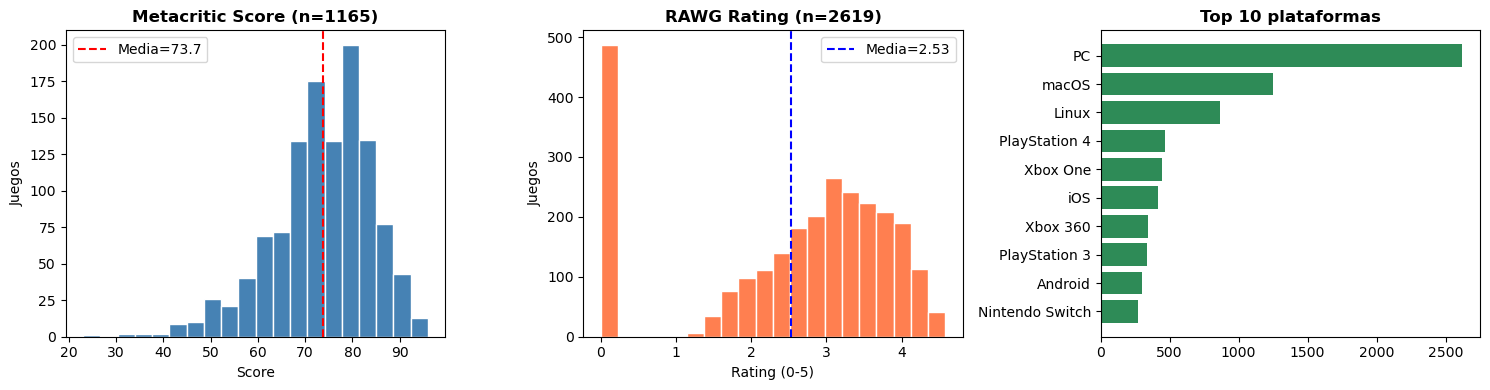

=== COBERTURA DE DATOS RAWG ===
  metacritic            : 1165 / 3195  (36.5%)
  rawg_rating           : 2619 / 3195  (82.0%)
  rawg_ratings_count    : 2619 / 3195  (82.0%)
  playtime_avg_h        : 2619 / 3195  (82.0%)
  esrb_rating           :  923 / 3195  (28.9%)


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribucion metacritic
mc = df_rawg['metacritic'].dropna()
axes[0].hist(mc, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title(f'Metacritic Score (n={len(mc)})', fontweight='bold')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Juegos')
axes[0].axvline(mc.mean(), color='red', linestyle='--', label=f'Media={mc.mean():.1f}')
axes[0].legend()

# Distribucion RAWG rating
rr = df_rawg['rawg_rating'].dropna()
axes[1].hist(rr, bins=20, color='coral', edgecolor='white')
axes[1].set_title(f'RAWG Rating (n={len(rr)})', fontweight='bold')
axes[1].set_xlabel('Rating (0-5)'); axes[1].set_ylabel('Juegos')
axes[1].axvline(rr.mean(), color='blue', linestyle='--', label=f'Media={rr.mean():.2f}')
axes[1].legend()

# Plataformas mas comunes
from collections import Counter
all_plats = [p for row in df_rawg['platforms'].dropna() for p in (row if isinstance(row, list) else [])]
plat_counts = Counter(all_plats).most_common(10)
if plat_counts:
    labs, vals = zip(*plat_counts)
    axes[2].barh(labs, vals, color='seagreen')
    axes[2].set_title('Top 10 plataformas', fontweight='bold')
    axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Resumen cobertura
print('=== COBERTURA DE DATOS RAWG ===')
fields = ['metacritic','rawg_rating','rawg_ratings_count','playtime_avg_h','esrb_rating']
for fld in fields:
    if fld in df_rawg.columns:
        n = df_rawg[fld].notna().sum()
        print(f"  {fld:<22s}: {n:>4d} / {len(df_rawg)}  ({n/len(df_rawg)*100:.1f}%)")

## Archivos generados

| Archivo | Descripcion |
|---------|-------------|
| `../Data/rawg_enriched.jsonl` | Una linea JSON por juego (raw, append-friendly) |
| `../Data/rawg_enriched.csv`   | Tabla final con una fila por juego |
| `../Data/rawg_fetch_log.json` | Steam IDs ya procesados (para resume) |

**Siguiente paso:** `10b_model_enriched.ipynb` — usar `metacritic`, `rawg_rating`, `playtime_avg_h` y `esrb_rating` como features adicionales junto a RS embeddings + review text para construir el Modelo 10.